In [2]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
orders = pd.read_csv(r'C:\Users\Ayoub-PC\Desktop\Olist Analysis Project\Data\Raw\olist_orders_dataset.csv')
customers = pd.read_csv(r'C:\Users\Ayoub-PC\Desktop\Olist Analysis Project\Data\Raw\olist_customers_dataset.csv')   
products = pd.read_csv(r'C:\Users\Ayoub-PC\Desktop\Olist Analysis Project\Data\Raw\olist_products_dataset.csv')
order_items = pd.read_csv(r'C:\Users\Ayoub-PC\Desktop\Olist Analysis Project\Data\Raw\olist_order_items_dataset.csv')
sellers = pd.read_csv(r'C:\Users\Ayoub-PC\Desktop\Olist Analysis Project\Data\Raw\olist_sellers_dataset.csv')
order_payments = pd.read_csv(r'C:\Users\Ayoub-PC\Desktop\Olist Analysis Project\Data\Raw\olist_order_payments_dataset.csv')
order_reviews = pd.read_csv(r'C:\Users\Ayoub-PC\Desktop\Olist Analysis Project\Data\Raw\olist_order_reviews_dataset.csv')  
geolocation = pd.read_csv(r'C:\Users\Ayoub-PC\Desktop\Olist Analysis Project\Data\Raw\olist_geolocation_dataset.csv')  
Translation = pd.read_csv(r'C:\Users\Ayoub-PC\Desktop\Olist Analysis Project\Data\Raw\product_category_name_translation.csv')  

### EDA Questions 
- What is the best / least performing product ? 
- Which product made the most revenue ? 
- What is the most / Least performing region ? 
- Who is the best / Least seller ? 
- When are we most selling / not selling ? 
- reviews analysis 
- delivery analysis 


## Most / Least sold product category 

In [4]:
order_items.head()  

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In order to show the most sold product category we need to merge order_items and products tables 

In [5]:
#merging order_items with products to get product details
order_items_products = order_items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')

In [6]:
order_items.head()  

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [7]:
order_items_products

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim
...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,utilidades_domesticas
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,informatica_acessorios
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,esporte_lazer
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,informatica_acessorios


In [8]:
order_items_products['product_category_name'].value_counts()

product_category_name
cama_mesa_banho                  11115
beleza_saude                      9670
esporte_lazer                     8641
moveis_decoracao                  8334
informatica_acessorios            7827
                                 ...  
cds_dvds_musicais                   14
la_cuisine                          14
pc_gamer                             9
fashion_roupa_infanto_juvenil        8
seguros_e_servicos                   2
Name: count, Length: 73, dtype: int64

Text(0.5, 1.0, 'Top 10 Most Sold Products')

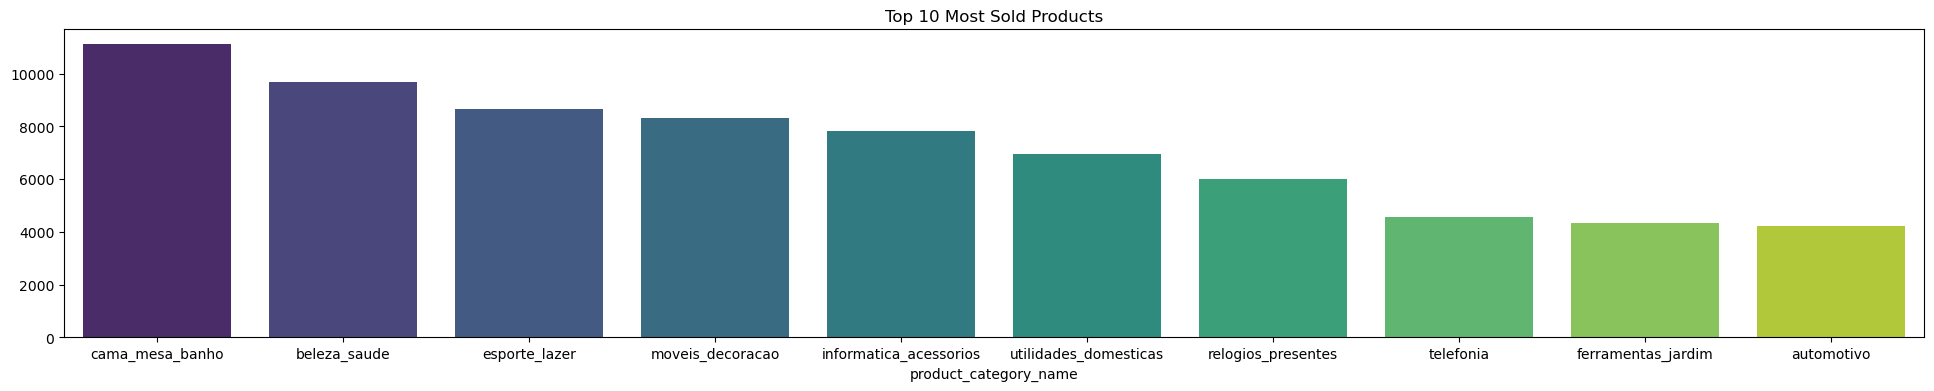

In [9]:
#Top 10 most sold products
top_products = order_items_products['product_category_name'].value_counts().head(10)
plt.figure(figsize=(24,4))
sns.barplot(x=top_products.index, y=top_products.values, palette='viridis')
plt.title('Top 10 Most Sold Products')

We noticed that the product categories is in portuguese so we will have to merge also with the translation table 

In [10]:
#merging order_items_products with translation to get product category names in English
order_items_products_translated = order_items_products.merge(Translation, left_on='product_category_name', right_on='product_category_name', how='left')

In [11]:
order_items_products_translated.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,garden_tools


Text(0.5, 1.0, 'Top 10 Most Sold Products translated')

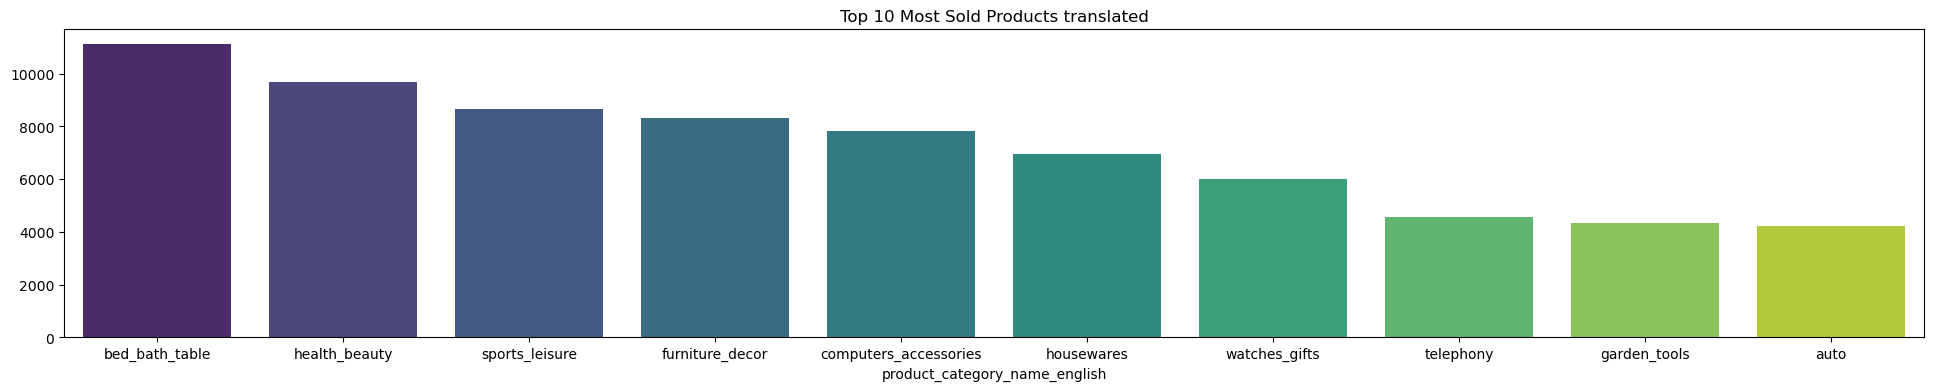

In [12]:
#Top 10 most sold products translated
top_products_translated = order_items_products_translated['product_category_name_english'].value_counts().head(10)
plt.figure(figsize=(24,4))
sns.barplot(x=top_products_translated.index, y=top_products_translated.values, palette='viridis')
plt.title('Top 10 Most Sold Products translated')
            

Text(0.5, 1.0, 'Top 10 Least Sold Products Translated')

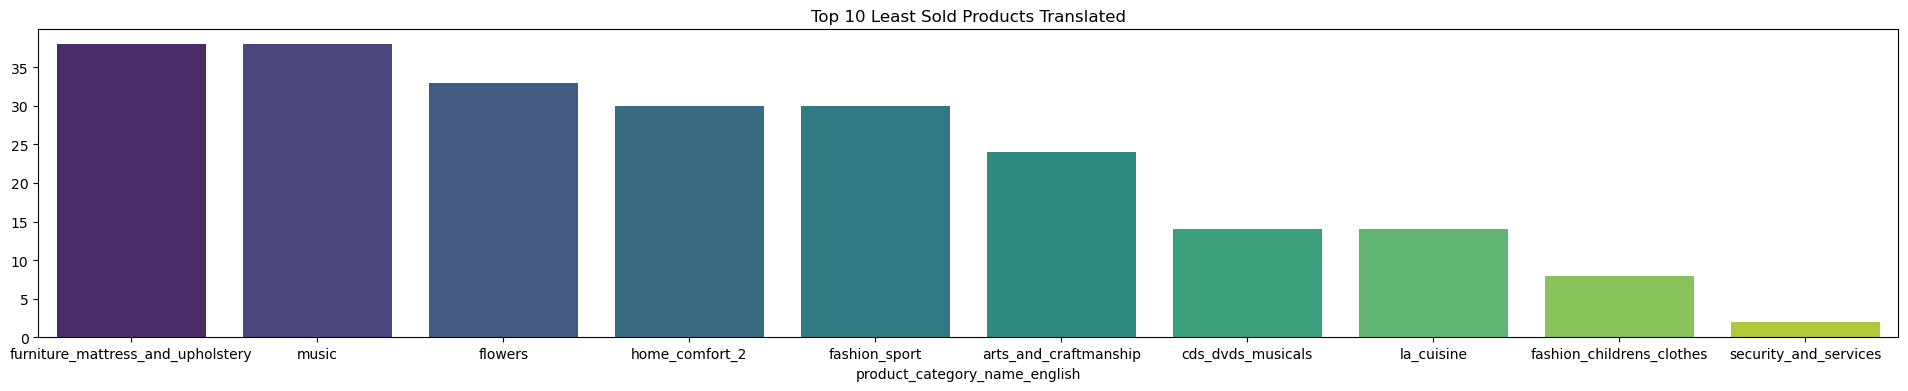

In [13]:
#Top 10 least sold products translated
top_products_translated = order_items_products_translated['product_category_name_english'].value_counts().tail(10)
plt.figure(figsize=(24,4))
sns.barplot(x=top_products_translated.index, y=top_products_translated.values, palette='viridis')
plt.title('Top 10 Least Sold Products Translated')

## Products revenues

Now We will try to figure out what product generated the most revenue

In [14]:
order_items_products_translated.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,garden_tools


In order to know the total value of the order 
- one order could include more than one item
- The total order_item value = Price * number of items 
- The total freight value = freight * number of items 
- The total order value (product + freight)

In [15]:
#created a column calculating total order value in order_items_products_translated
order_items_products_translated['total_order_value'] = (
    order_items_products_translated['price']
    + order_items_products_translated['freight_value']
      * order_items_products_translated['order_item_id']
)
order_items_products_translated.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english,total_order_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,cool_stuff,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,pet_shop,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,furniture_decor,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,perfumery,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,garden_tools,218.04


Text(0.5, 1.0, 'Top 10 Products by Revenue')

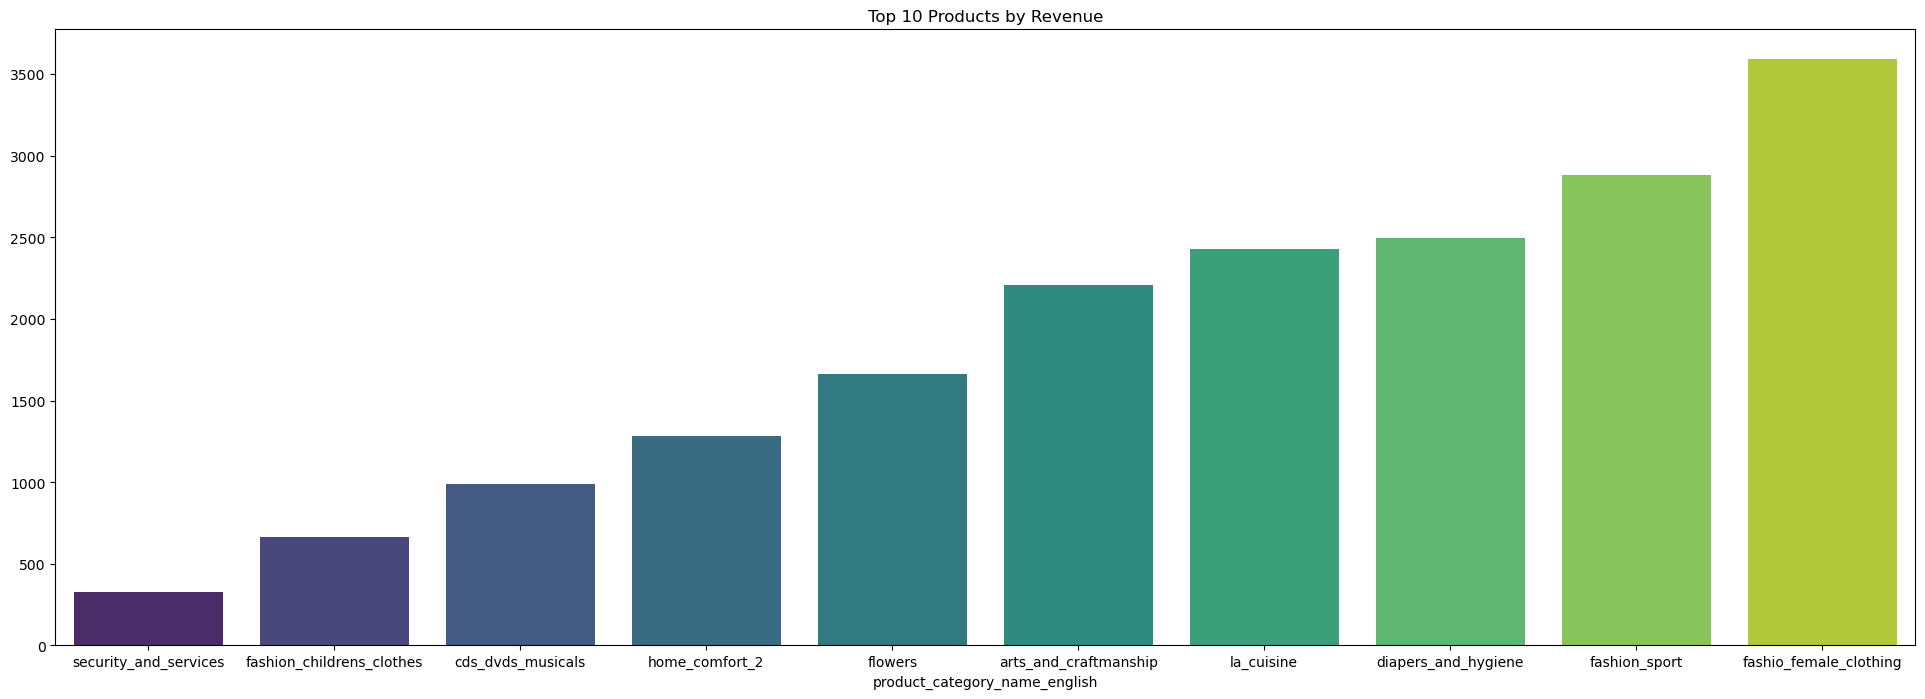

In [16]:
#top 10 products with most revenues
top_revenue_products = order_items_products_translated.groupby('product_category_name_english')['total_order_value'].sum().sort_values(ascending=True).head(10)
plt.figure(figsize=(24,8))
sns.barplot(x=top_revenue_products.index, y=top_revenue_products.values, palette='viridis')
plt.title('Top 10 Products by Revenue')

Text(0.5, 1.0, 'Top 10 Products by Revenue')

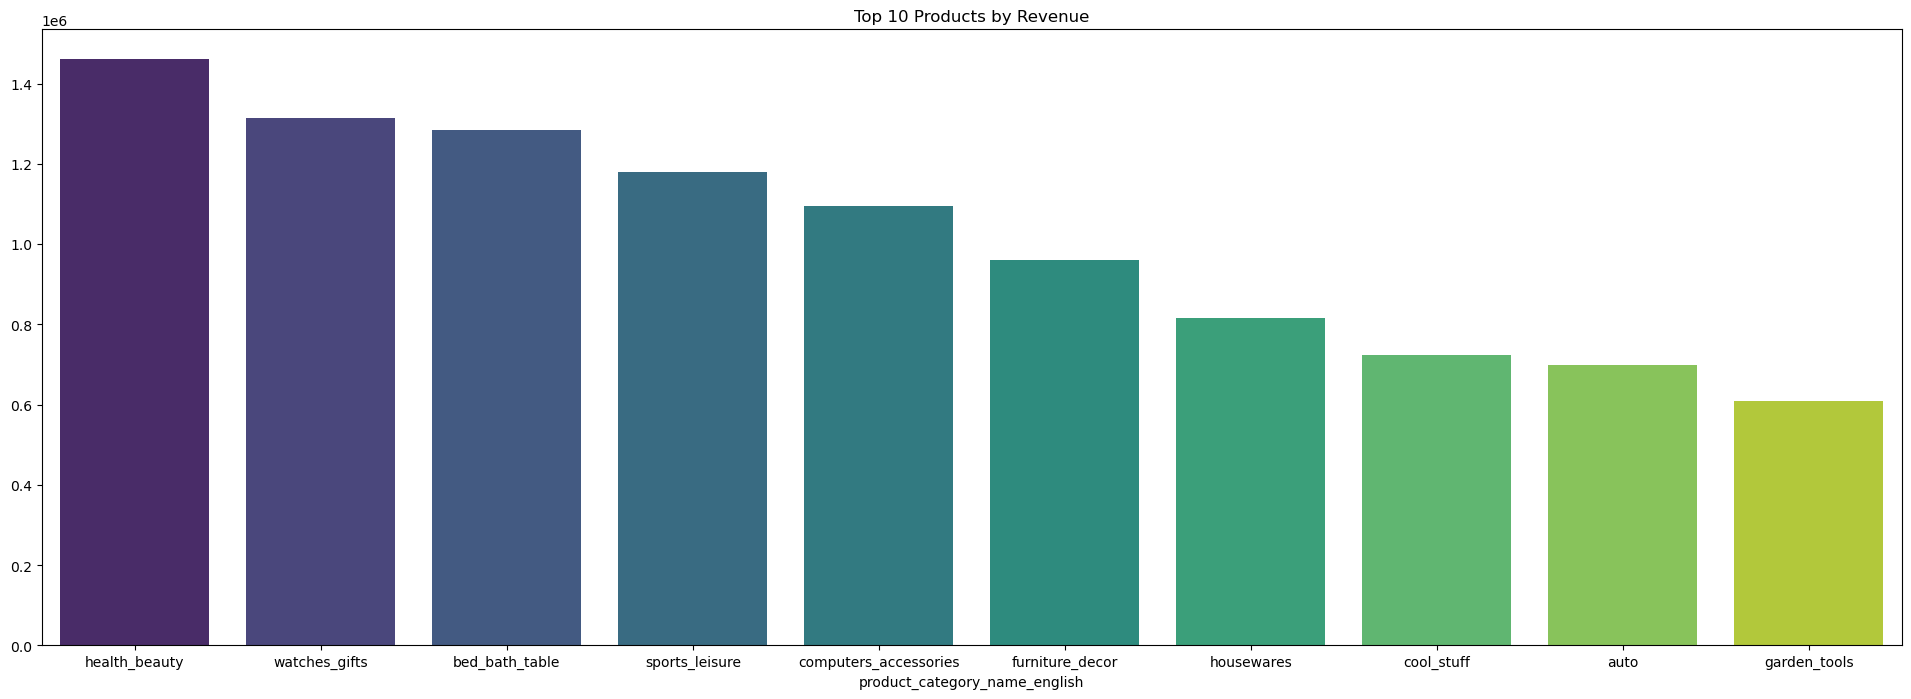

In [17]:
#top 10 products with least revenues
least_revenue_products = order_items_products_translated.groupby('product_category_name_english')['total_order_value'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(24,8))
sns.barplot(x=least_revenue_products.index, y=least_revenue_products.values, palette='viridis')
plt.title('Top 10 Products by Revenue')

## Regions Performance 

Now we will try to assess the performance of the regions 

In [18]:
customers.head()    

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [19]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [20]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [21]:
customers['customer_unique_id'].value_counts()

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
ca77025e7201e3b30c44b472ff346268     7
6469f99c1f9dfae7733b25662e7f1782     7
                                    ..
081f07439678af2da7755a0aa572154d     1
9c57789a6a587f4efcfb01e36c106014     1
9e4c21635f640562de1a6976374fba03     1
06c0ea6ee892364d1608ee47aa9f56a0     1
84732c5050c01db9b23e19ba39899398     1
Name: count, Length: 96096, dtype: int64

In [22]:
customers['customer_state'].value_counts()

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

Text(0.5, 1.0, 'Customer Distribution by State')

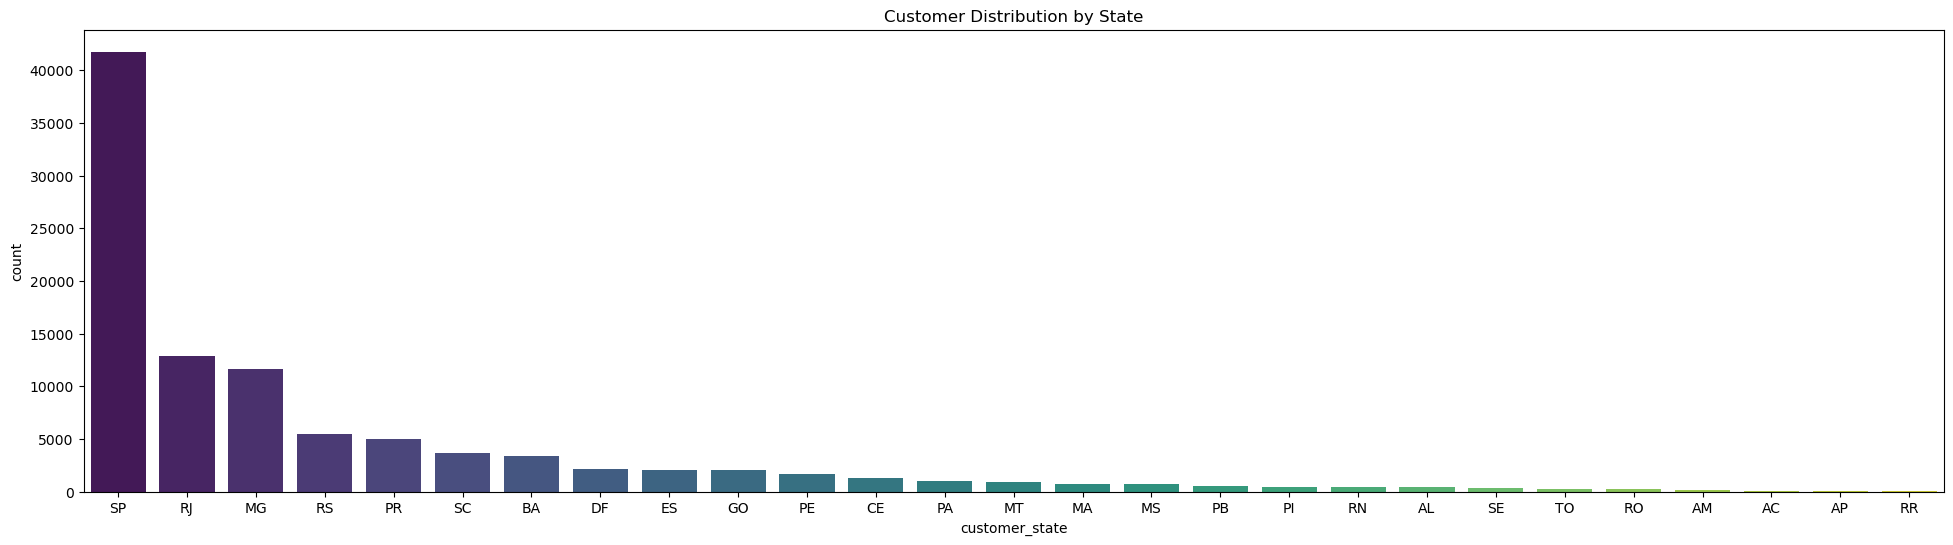

In [23]:
#plotting customer distribution by state
plt.figure(figsize=(24,6))
sns.countplot(x='customer_state', data=customers, order=customers['customer_state'].value_counts().index, palette='viridis')
plt.title('Customer Distribution by State')

Now we know the states with the most customers 

## Sales overtime Analysis 

Now we are going to see what are the times in which we're selling the most 

In [24]:
orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [25]:
#first convert 'order_purchase_timestamp' to datetime
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

In [26]:
orders['purchase_hour'] = orders['order_purchase_timestamp'].dt.hour
orders_by_hour = (
    orders['purchase_hour']
    .value_counts()
    .sort_values()
)
orders_by_hour

purchase_hour
5      188
4      206
3      272
6      502
2      510
1     1170
7     1231
0     2394
8     2967
23    4123
9     4785
18    5769
22    5816
19    5982
12    5995
17    6150
10    6177
20    6193
21    6217
15    6454
13    6518
14    6569
11    6578
16    6675
Name: count, dtype: int64

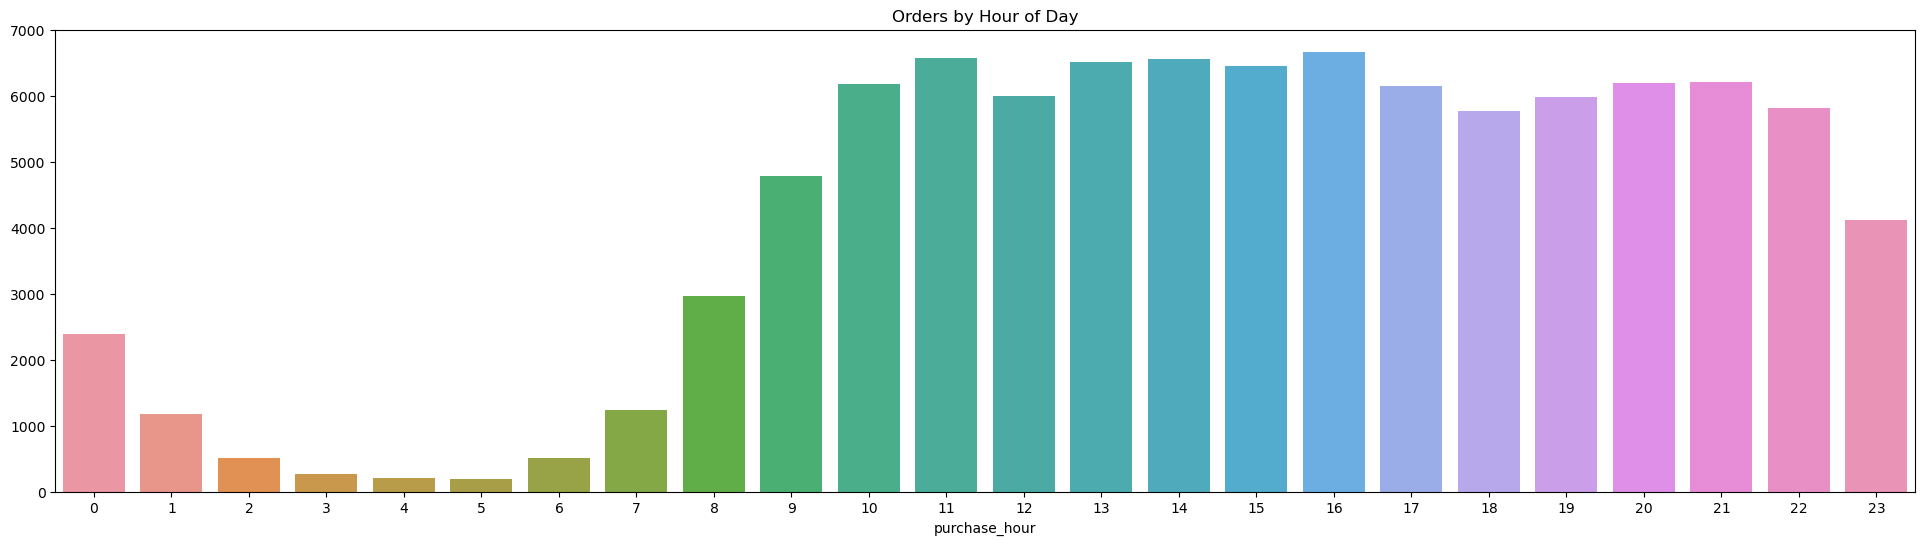

In [27]:
plt.figure(figsize=(24,6))
sns.barplot(x=orders_by_hour.index, y=orders_by_hour.values) 
plt.title('Orders by Hour of Day')
plt.show()

In [28]:
orders['purchase_day'] = orders['order_purchase_timestamp'].dt.day_name()
orders_by_day = (
    orders['purchase_day']
    .value_counts()
    .sort_index()
)
orders_by_day

purchase_day
Friday       14122
Monday       16196
Saturday     10887
Sunday       11960
Thursday     14761
Tuesday      15963
Wednesday    15552
Name: count, dtype: int64

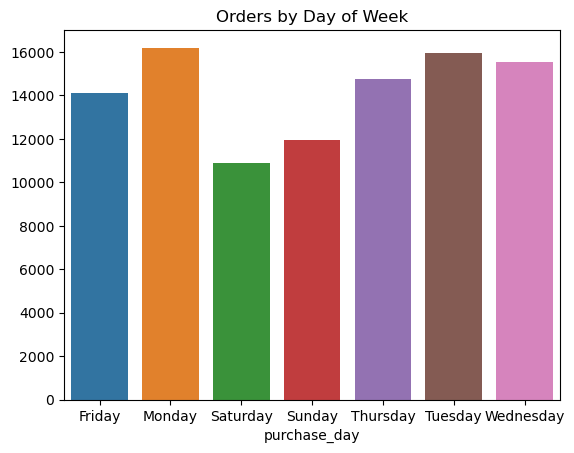

In [29]:
sns.barplot(x=orders_by_day.index, y=orders_by_day.values)
plt.title('Orders by Day of Week')
plt.show()


In [30]:
orders['purchase_month'] = orders['order_purchase_timestamp'].dt.month
orders_by_month = (
    orders['purchase_month']
    .value_counts()
    .sort_values()
)
orders_by_month

purchase_month
9      4305
10     4959
12     5674
11     7544
1      8069
2      8508
4      9343
6      9412
3      9893
7     10318
5     10573
8     10843
Name: count, dtype: int64

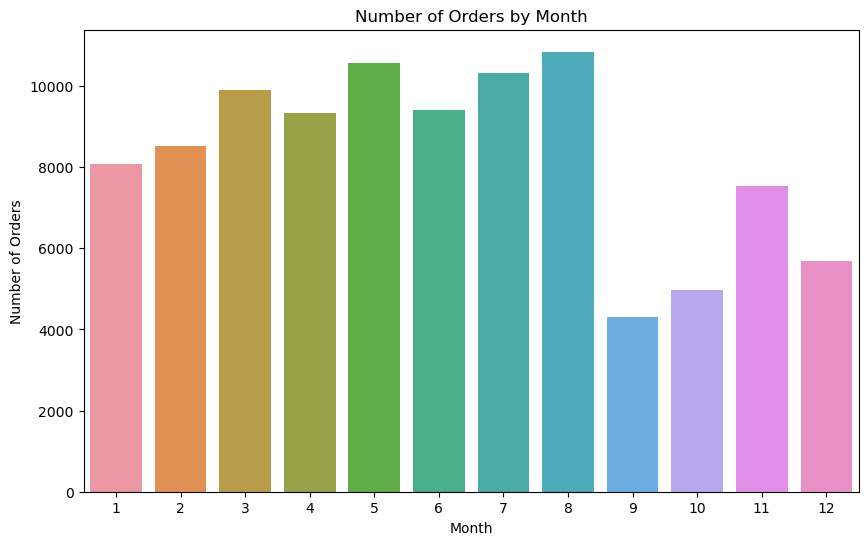

In [31]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=orders_by_month.index,
    y=orders_by_month.values
)
plt.title('Number of Orders by Month')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.show()


C:\Users\Ayoub-PC\AppData\Local\Temp\ipykernel_20316\3233418421.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=orders_by_month.index, y=orders_by_month.values, palette='viridis')
c:\Users\Ayoub-PC\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Ayoub-PC\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


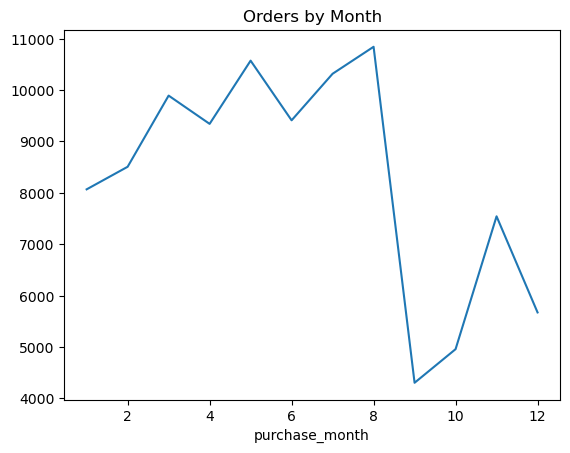

In [32]:
sns.lineplot(x=orders_by_month.index, y=orders_by_month.values, palette='viridis') 
plt.title('Orders by Month')
plt.show()

We figured out which times we are selling the most and which time are we selling less, that way we can optimize our efforts to sell more on the times that are not performing. 

## Reviews Analysis 

Now we are going to analyze the reviews 

- We have a review score between 1 and 5 
- we have the order_id and which we can understand the category of the product which got the good/bad reviews 
- we can see first the average review 

In [33]:
#merge the reviews with order_items_products_translated on 'order_id'
order_items_products_translated_reviews = order_items_products_translated.merge(order_reviews[['order_id', 'review_score']], on='order_id', how='left')

In [34]:
order_items_products_translated_reviews

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english,total_order_value,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,cool_stuff,72.19,5.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,pet_shop,259.83,4.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,furniture_decor,216.87,5.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,perfumery,25.78,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,garden_tools,218.04,5.0
...,...,...,...,...,...,...,...,...,...,...,...
113309,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,utilidades_domesticas,housewares,343.40,5.0
113310,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,informatica_acessorios,computers_accessories,386.53,5.0
113311,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,esporte_lazer,sports_leisure,116.85,5.0
113312,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,informatica_acessorios,computers_accessories,64.71,5.0


In [35]:
top_reviewed_products = order_items_products_translated_reviews.groupby('product_category_name_english')['review_score'].mean().sort_values(ascending=False).head(10)
top_reviewed_products

product_category_name_english
cds_dvds_musicals                        4.642857
fashion_childrens_clothes                4.500000
books_general_interest                   4.446266
costruction_tools_tools                  4.444444
flowers                                  4.419355
books_imported                           4.400000
books_technical                          4.368421
food_drink                               4.315412
luggage_accessories                      4.315257
small_appliances_home_oven_and_coffee    4.302632
Name: review_score, dtype: float64

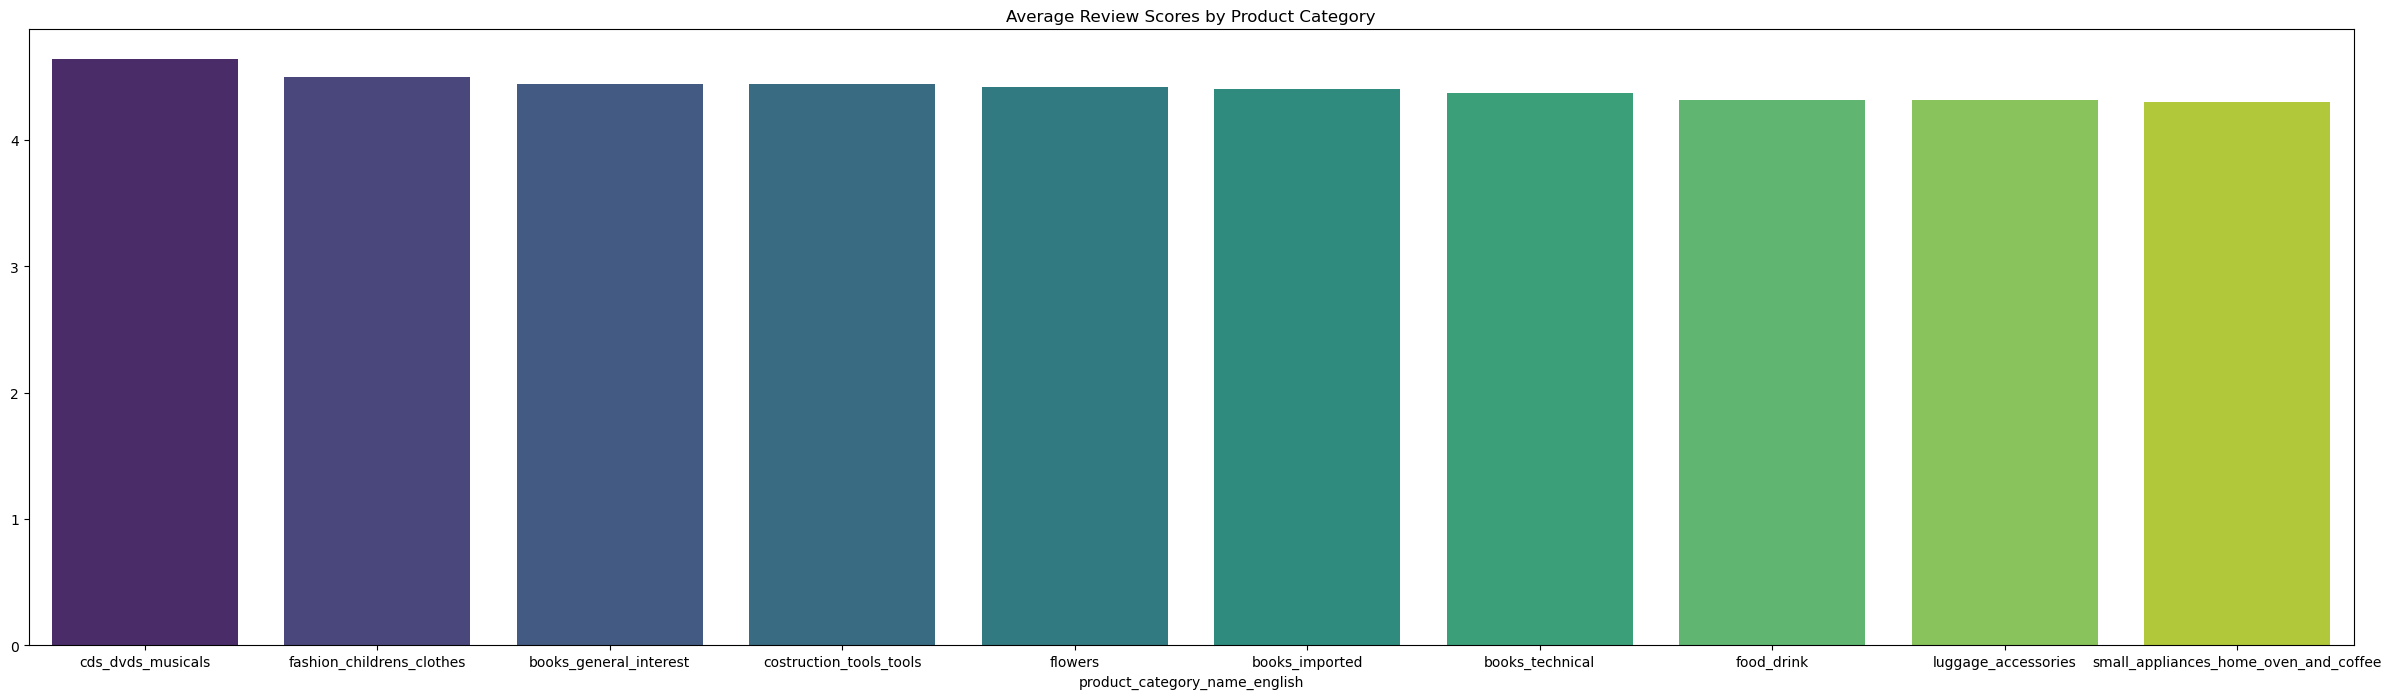

In [36]:
top_reviewed_products = order_items_products_translated_reviews.groupby('product_category_name_english')['review_score'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(30,8))
sns.barplot(x=top_reviewed_products.index, y=top_reviewed_products.values, palette='viridis')
plt.title('Average Review Scores by Product Category')
plt.show()

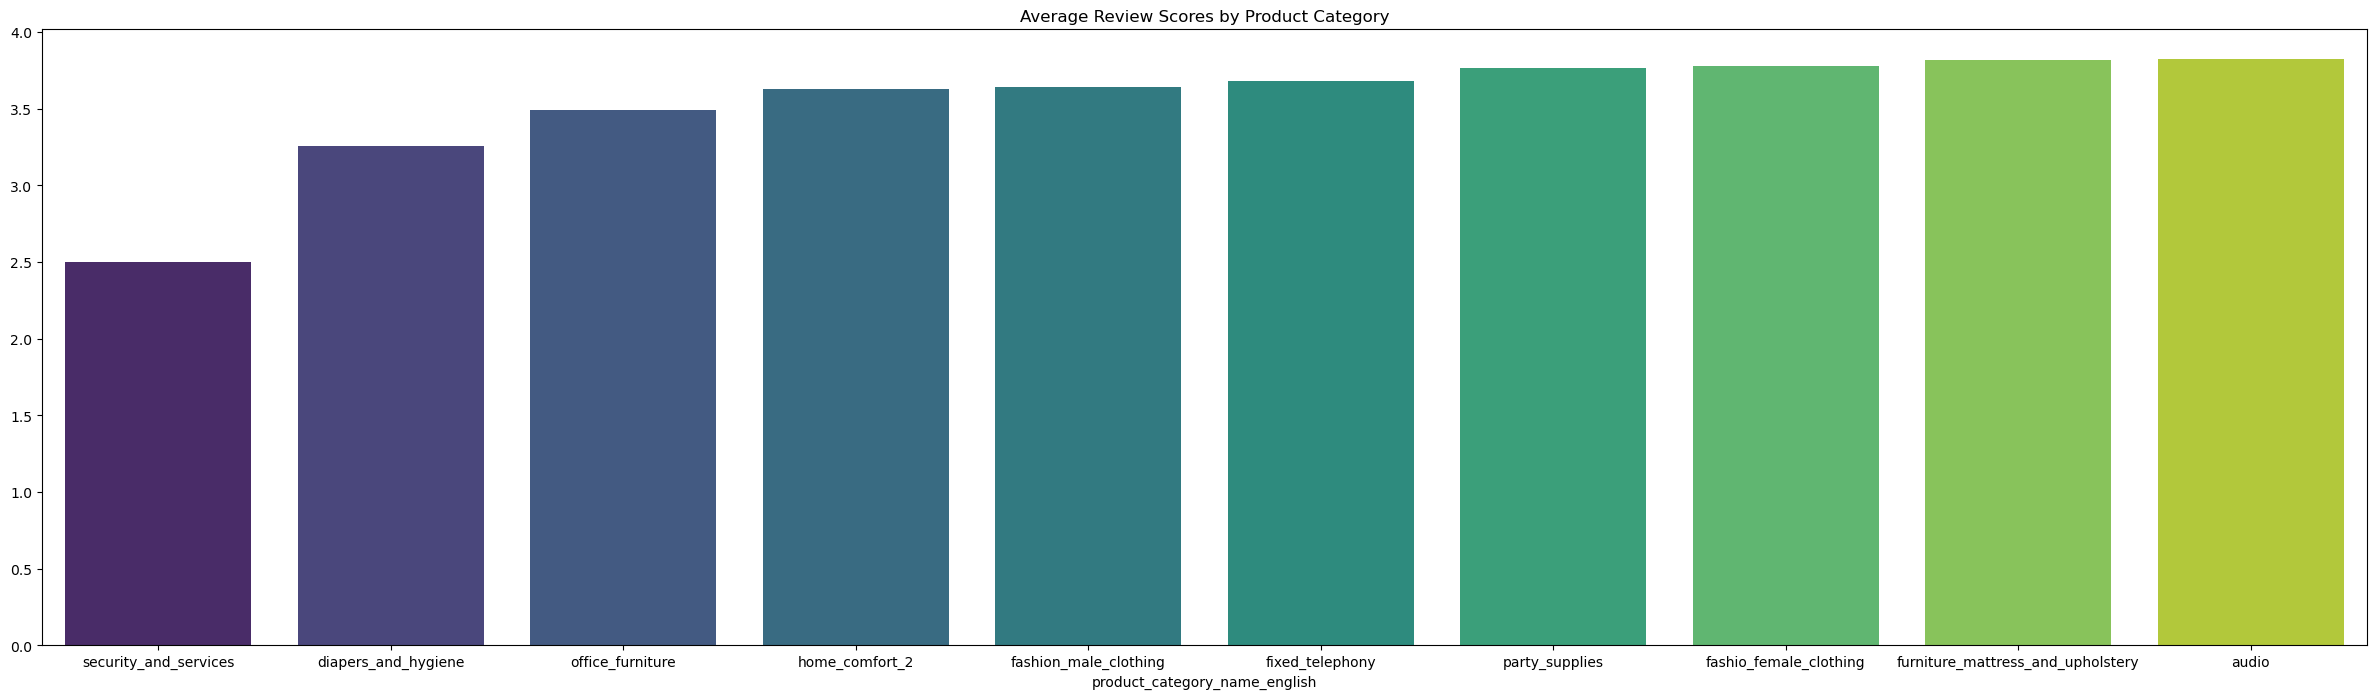

In [37]:
least_reviewed_products = order_items_products_translated_reviews.groupby('product_category_name_english')['review_score'].mean().sort_values(ascending=True).head(10)
plt.figure(figsize=(30,8))
sns.barplot(x=least_reviewed_products.index, y=least_reviewed_products.values, palette='viridis')
plt.title('Average Review Scores by Product Category')
plt.show()

Now we analyze the delivery 

## Delivery Analysis 

What's important to us in the delivery is the comparison between : 
- order purchase timestap & order delivered customer date 
- order_estimated_delivery_date & order delivered customer date

In [38]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_hour,purchase_day,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,10,Monday,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,20,Tuesday,7
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,8,Wednesday,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,19,Saturday,11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,21,Tuesday,2


In [ ]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)
orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date']
)
orders['order_estimated_delivery_date'] = pd.to_datetime(
    orders['order_estimated_delivery_date']
)


In [40]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_hour,purchase_day,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,10,Monday,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,20,Tuesday,7
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,8,Wednesday,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,19,Saturday,11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,21,Tuesday,2


In [41]:
#Delivery vs estimated date

orders['delivery_delay'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date'])
orders['delivery_delay'].describe()

count                           96476
mean     -12 days +19:42:04.042383598
std        10 days 04:28:00.181984555
min               -147 days +23:36:47
25%         -17 days +18:08:05.250000
50%         -12 days +01:13:31.500000
75%                 -7 days +14:38:24
max                 188 days 23:24:07
Name: delivery_delay, dtype: object

In [42]:
#Delivery vs estimated date

delivered_orders = orders[orders['order_status'] == 'delivered'].copy()

delivered_orders['delivery_delay'] = (
    delivered_orders['order_delivered_customer_date']
    - delivered_orders['order_estimated_delivery_date']
)

delivered_orders['delivery_delay'].describe()


count                           96470
mean     -12 days +19:43:29.937027056
std        10 days 04:25:28.179310468
min               -147 days +23:36:47
25%         -17 days +18:08:32.750000
50%                -12 days +01:14:44
75%                 -7 days +14:38:40
max                 188 days 23:24:07
Name: delivery_delay, dtype: object

In [43]:
delivered_orders['delivery_delay_days'] = (
    delivered_orders['delivery_delay'].dt.days
)

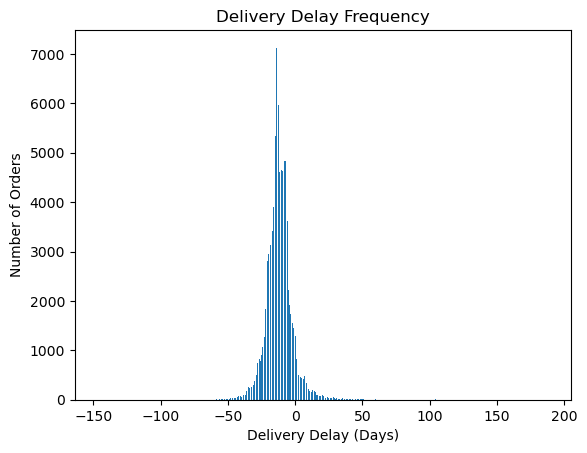

In [44]:
plt.figure()
plt.hist(delivered_orders['delivery_delay_days'].dropna(), bins=500)
plt.xlabel('Delivery Delay (Days)')
plt.ylabel('Number of Orders')
plt.title('Delivery Delay Frequency')
plt.show()


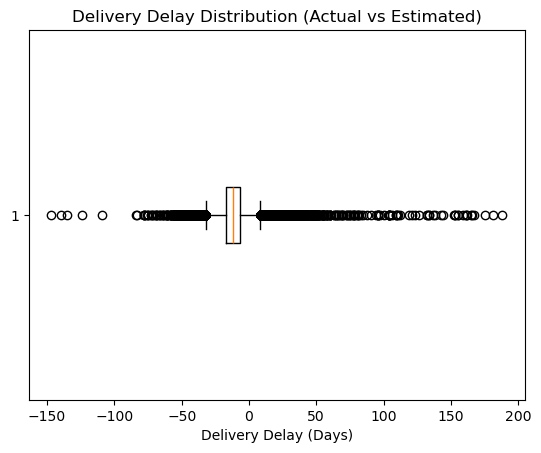

In [45]:
plt.figure()
plt.boxplot(delivered_orders['delivery_delay_days'].dropna(), vert=False)
plt.xlabel('Delivery Delay (Days)')
plt.title('Delivery Delay Distribution (Actual vs Estimated)')
plt.show()


In [46]:
#Delivery vs purchase date
orders['purchase_to_delivery'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp'])
orders['purchase_to_delivery'].describe()

count                         96476
mean     12 days 13:24:31.879068369
std       9 days 13:07:00.181125305
min                 0 days 12:48:07
25%          6 days 18:23:37.250000
50%                10 days 05:13:34
75%         15 days 17:17:16.250000
max               209 days 15:05:12
Name: purchase_to_delivery, dtype: object

In [47]:
#Delivery vs purchase date

delivered_orders = orders[orders['order_status'] == 'delivered'].copy()

delivered_orders['purchase_to_delivery'] = (
    delivered_orders['order_delivered_customer_date']
    - delivered_orders['order_purchase_timestamp']
)

delivered_orders['purchase_to_delivery'].describe()


count                         96470
mean     12 days 13:23:49.957271690
std       9 days 13:06:27.911052929
min                 0 days 12:48:07
25%                 6 days 18:23:20
50%                10 days 05:13:10
75%         15 days 17:17:03.750000
max               209 days 15:05:12
Name: purchase_to_delivery, dtype: object

In [48]:
orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_hour,purchase_day,purchase_month,delivery_delay,purchase_to_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,10,Monday,10,-8 days +21:25:13,8 days 10:28:40
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,20,Tuesday,7,-6 days +15:27:45,13 days 18:46:08
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,8,Wednesday,8,-18 days +18:06:29,9 days 09:27:40
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,19,Saturday,11,-13 days +00:28:42,13 days 05:00:36
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,21,Tuesday,2,-10 days +18:17:02,2 days 20:58:23
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,9,Thursday,3,-11 days +15:08:01,8 days 05:13:56
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,12,Tuesday,2,-2 days +17:37:56,22 days 04:38:58
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,14,Sunday,8,-6 days +11:24:17,24 days 20:37:34
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,21,Monday,1,-21 days +23:32:54,17 days 02:04:27


In [55]:
#order delays where order was delivered on time
delivered_orders['delivery_delay_days'] = (
    delivered_orders['delivery_delay'].dt.days
)
on_time_deliveries = delivered_orders[delivered_orders['delivery_delay_days'] <= 0]
on_time_deliveries

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_hour,purchase_day,purchase_month,delivery_delay,purchase_to_delivery,delivery_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,10,Monday,10,-8 days +21:25:13,8 days 10:28:40,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,20,Tuesday,7,-6 days +15:27:45,13 days 18:46:08,-6.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,8,Wednesday,8,-18 days +18:06:29,9 days 09:27:40,-18.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,19,Saturday,11,-13 days +00:28:42,13 days 05:00:36,-13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,21,Tuesday,2,-10 days +18:17:02,2 days 20:58:23,-10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,9,Thursday,3,-11 days +15:08:01,8 days 05:13:56,-11.0
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,12,Tuesday,2,-2 days +17:37:56,22 days 04:38:58,-2.0
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,14,Sunday,8,-6 days +11:24:17,24 days 20:37:34,-6.0
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,21,Monday,1,-21 days +23:32:54,17 days 02:04:27,-21.0


In [56]:
orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_hour,purchase_day,purchase_month,delivery_delay,purchase_to_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,10,Monday,10,-8 days +21:25:13,8 days 10:28:40
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,20,Tuesday,7,-6 days +15:27:45,13 days 18:46:08
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,8,Wednesday,8,-18 days +18:06:29,9 days 09:27:40
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,19,Saturday,11,-13 days +00:28:42,13 days 05:00:36
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,21,Tuesday,2,-10 days +18:17:02,2 days 20:58:23
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,9,Thursday,3,-11 days +15:08:01,8 days 05:13:56
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,12,Tuesday,2,-2 days +17:37:56,22 days 04:38:58
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,14,Sunday,8,-6 days +11:24:17,24 days 20:37:34
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,21,Monday,1,-21 days +23:32:54,17 days 02:04:27
